# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from datetime import datetime
from oceanicospy.retrievals.download_CMDS_data import CMDSDownloader
from oceanicospy.observations import Buoy
from oceanicospy.observations import WeatherStation
from oceanicospy.retrievals.download_ERA5_data import ERA5Downloader

ModuleNotFoundError: No module named 'xarray'

# Weather data

In [2]:
# Path where the DAVIS weather station .txt file is located
davis_path = r"/scratchsan/medellin/lroserom/test_oceanicospy/data/raw/weather"

# Create instance of WeatherStation class
davis_WS = WeatherStation(davis_path)

# Get cleaned records
davis_df = davis_WS.get_clean_records()
davis_df

,Temp1,Temp2,Speed,Dir1,Run,Speed2,Dir2,Bar,Rain,Rate,...,Hum2,Dew,Heat,EMC,Density,Samp,Tx,Recept,Int.,Direction
date,,,,,,,,,,,,,,,,,,,,,
2023-08-19 00:15:00,NaN,NaN,0.0,NaN,0.00,0.0,NaN,1011.7,0.00,0.0,...,79,24.8,34.2,15.47,1.1319,0,1,0.0,15,NaN
2023-08-19 00:30:00,NaN,NaN,0.0,NaN,0.00,0.0,NaN,1011.6,0.00,0.0,...,78,24.4,33.7,15.18,1.1329,0,1,0.0,15,NaN
2023-08-19 00:45:00,NaN,NaN,0.0,NaN,0.00,0.0,NaN,1011.3,0.00,0.0,...,78,24.2,33.1,15.19,1.1339,0,1,0.0,15,NaN
2023-08-19 01:00:00,NaN,NaN,0.0,NaN,0.00,0.0,NaN,1011.1,0.00,0.0,...,80,24.8,33.8,15.81,1.1321,0,1,0.0,15,NaN
2023-08-19 01:15:00,NaN,NaN,0.0,NaN,0.00,0.0,NaN,1010.8,0.00,0.0,...,81,25.1,34.3,16.21,1.1307,0,1,0.0,15,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31 15:30:00,NaN,NaN,0.4,NNE,0.40,4.0,NNE,1008.9,0.00,0.0,...,77,27.7,43.9,14.55,1.1094,292,1,85.4,15,22.5
2023-08-31 15:45:00,NaN,NaN,1.8,NNE,1.61,4.5,ENE,1008.8,0.00,0.0,...,76,27.5,43.4,14.25,1.1098,295,1,86.3,15,22.5
2023-08-31 16:00:00,NaN,NaN,4.5,ENE,4.02,7.6,ENE,1008.8,0.00,0.0,...,76,27.5,43.4,14.25,1.1097,282,1,82.5,15,67.5


# CMDS data

In [3]:

# winds_CMDS = CMDSDownloader.for_winds(
#     dataset_id="cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H",  
#     variables=["eastward_wind", "northward_wind"],               
#     lon_min=-82,
#     lon_max=-81,
#     lat_min=12,
#     lat_max=13,
#     start_datetime_local=datetime(2023, 8, 1, 0, 0),             
#     end_datetime_local=datetime(2023, 8, 31, 23, 0),               
#     difference_to_UTC=-5,                                       
#     output_path="/scratchsan/medellin/lroserom/test_oceanicospy/data/raw/winds_CMDS",
#     file_format="netcdf",
#     output_filename="winds_CMDS.nc"                             
# )


# winds_CMDS.download()

# winds_CMDS.format_to_localtime()

In [4]:
path = '/scratchsan/medellin/lroserom/test_oceanicospy/data/raw/winds_CMDS/'
winds_CMDS = xr.open_dataset(path+'winds_CMDS.nc') 
winds_CMDS

<xarray.Dataset> Size: 768kB
Dimensions:         (time: 744, latitude: 8, longitude: 8)
Coordinates:
  * latitude        (latitude) float32 32B 12.06 12.19 12.31 ... 12.81 12.94
  * longitude       (longitude) float32 32B -81.94 -81.81 ... -81.19 -81.06
  * time            (time) datetime64[ns] 6kB 2023-08-01 ... 2023-08-31T23:00:00
Data variables:
    eastward_wind   (time, latitude, longitude) float64 381kB ...
    northward_wind  (time, latitude, longitude) float64 381kB ...
Attributes:
    references:                Copernicus Marine Service Product User Manual ...
    Conventions:               CF-1.6, ACDD-1.3
    title:                      Global Ocean - Wind and Stress - Hourly - Fro...
    institution:               Royal Netherlands Meteorological Institute (KNMI)
    history:                   N/A
    copernicusmarine_version:  2.2.1

In [5]:
# Convert the Dataset to a DataFrame
df = winds_CMDS.to_dataframe().reset_index()

# Keep only the desired columns: time, lat, lon, and variables
ordered_cols = ['time', 'latitude', 'longitude'] + list(winds_CMDS.data_vars)
df = df[ordered_cols]

# Ensure time is datetime (kept as a column; set as index if you prefer)
df['time'] = pd.to_datetime(df['time'])
df = df[(df['latitude'] == 12.5625) & (df['longitude'] == -81.6875)]
# ----- Add derived wind quantities -----
# Wind speed (velocity magnitude) in the same units as components (typically m/s)
df['wind_velocity'] = np.hypot(df['eastward_wind'], df['northward_wind'])

# Wind direction in degrees, clockwise from North (0°=N, 90°=E, 180°=S, 270°=W)
# This gives the direction TOWARD which the vector points,
# consistent with using components (u=eastward, v=northward).
theta_rad = np.arctan2(df['eastward_wind'], df['northward_wind'])
df['wind_dir'] = np.degrees(theta_rad) % 360.0

# Optional: set time as index and reorder columns exactly as requested
df = df.set_index('time')
df = df[['latitude', 'longitude', 'eastward_wind', 'northward_wind', 'wind_velocity', 'wind_dir']]

print(df.head())

                     latitude  longitude  eastward_wind  northward_wind  \
time                                                                      
2023-08-01 00:00:00   12.5625   -81.6875          -6.84           -2.93   
2023-08-01 01:00:00   12.5625   -81.6875          -6.99           -1.09   
2023-08-01 02:00:00   12.5625   -81.6875          -8.35           -2.93   
2023-08-01 03:00:00   12.5625   -81.6875          -8.06           -2.31   
2023-08-01 04:00:00   12.5625   -81.6875          -7.21           -1.39   

                     wind_velocity    wind_dir  
time                                            
2023-08-01 00:00:00       7.441136  246.811520  
2023-08-01 01:00:00       7.074475  261.136845  
2023-08-01 02:00:00       8.849147  250.664120  
2023-08-01 03:00:00       8.384492  254.007671  
2023-08-01 04:00:00       7.342765  259.087948  


# Buoy data

In [6]:
directory_path = r'/scratchsan/medellin/lroserom/test_oceanicospy/data/raw/Buoy/Out_Reef/Spotter_Aqualink_Format'

sampling_data = {
    'start_time': '2023-08-01 00:00:00',
    'end_time': '2023-08-31 23:00:00'
}

buoy = Buoy(directory_path=directory_path, sampling_data=sampling_data)
df_raw = buoy._load_raw_dataframe()
df_std = buoy._standardize_columns(df_raw)
df_bursts = buoy._assign_burst_id(df_std)
df_buoy = buoy._parse_dates_and_trim(df_bursts)
df_buoy

/homes/medellin/lroserom/oceanicospy/oceanicospy/observations/buoy.py:129: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['burstId'] = pd.factorize(df.index.floor('H'))[0] + 1


,timestamp,wind_speed_gfs,wind_direction_gfs,temp_alert_noaa,temp_weekly_alert_noaa,dhw_noaa,satellite_temperature_noaa,sst_anomaly_noaa,TempTop[°C],TempBottom[°C],Hs[m],Tp[s],Dir[°],Wind[m/s],WindDir[°],significant_wave_height_sofar_model,wave_mean_period_sofar_model,wave_mean_direction_sofar_model,burstId
date,,,,,,,,,,,,,,,,,,,
2023-08-01 01:00:00,2023-08-01T06:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.785,13.29,110.6200,2.0,131.0,NaN,NaN,NaN,9671
2023-08-01 13:00:00,2023-08-01T18:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.880000,NaN,1.510,7.72,61.3885,3.8,79.5,NaN,NaN,NaN,9672
2023-08-01 15:00:00,2023-08-01T20:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.920000,NaN,1.490,6.68,48.8895,4.0,31.0,NaN,NaN,NaN,9673
2023-08-01 17:00:00,2023-08-01T22:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.900000,28.900000,1.600,5.91,65.2855,4.8,54.0,NaN,NaN,NaN,9674
2023-08-01 19:00:00,2023-08-02T00:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.946667,28.913333,1.315,5.46,71.3475,4.2,99.5,NaN,NaN,NaN,9675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31 15:00:00,2023-08-31T20:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.330,5.28,86.6515,5.2,82.5,NaN,NaN,NaN,10027
2023-08-31 17:00:00,2023-08-31T22:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.400,5.51,89.9910,4.8,96.5,NaN,NaN,NaN,10028
2023-08-31 19:00:00,2023-09-01T00:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.335,5.69,89.9275,4.0,94.0,NaN,NaN,NaN,10029


# ERA 5 data

In [7]:
# variables = ["10m_u_component_of_wind",
#      "10m_v_component_of_wind",]
# # Spatial domain (WGS84); San Andrés example
# lon_min, lon_max = -81.90, -81.50   # West/East
# lat_min, lat_max =  12.35,  12.75   # South/North

# # Local time window (America/Bogota ~ UTC-5)
# start_local = datetime(2023, 8, 1, 0, 0)
# end_local   = datetime(2023, 8, 31, 23, 0)
# utc_offset_hours = -5  # Local = UTC-5

# # Output file
# output_nc = "/scratchsan/medellin/lroserom/test_oceanicospy/data/raw/winds_ERA5/wind_era5_SA_20230801_20230831.nc"

# # --- Instantiate and run ---
# winds_ERA5 = ERA5Downloader(
#     variables=variables,
#     lon_min=lon_min,
#     lon_max=lon_max,
#     lat_min=lat_min,
#     lat_max=lat_max,
#     start_datetime_local=start_local,
#     end_datetime_local=end_local,
#     difference_to_UTC=utc_offset_hours,
#     output_path=output_nc,
# )

# # 1) Download in UTC from CDS (hourly)
# winds_ERA5.download()
# winds_ERA5.format_to_localtime()

2025-08-14 16:26:18,791 INFO Request ID is ff0bb42f-8683-46c8-95e4-4aa1f95fa11d
2025-08-14 16:26:19,048 INFO status has been updated to accepted
2025-08-14 16:26:24,548 INFO status has been updated to running
2025-08-14 16:30:40,743 INFO status has been updated to successful


In [8]:
path = '/scratchsan/medellin/lroserom/test_oceanicospy/data/raw/winds_ERA5/'
winds_ERA5 = xr.open_dataset(path+'wind_era5_SA_20230801_20230831.nc') 
winds_ERA5

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 744, latitude: 17, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6kB 2023-08-01 ... 2023-08-31T23:...
  * latitude    (latitude) float64 136B 12.75 12.72 12.7 ... 12.4 12.37 12.35
  * longitude   (longitude) float64 136B -81.9 -81.88 -81.85 ... -81.52 -81.5
    expver      (valid_time) <U4 12kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 860kB ...
    v10         (valid_time, latitude, longitude) float32 860kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-14T16:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:
def build_point_df(ds, variables, lat, lon, method="nearest"):
    """
    Build a point-extracted DataFrame from an xarray.Dataset.
    Output columns: ['date', 'lat', 'lon', <variables...>].

    This version is robust to:
    - Different coord names (lat/latitude/y, lon/longitude/x, time/valid_time).
    - 0–360 longitude datasets (user may pass negative longitudes).
    - Variable aliases (e.g., 'swh' -> ERA5 SWH long name).
    - Time columns with/without timezone (avoids tz_localize errors).
    """
    # --- 1) Resolve coordinate names robustly ---
    coords_lower = {k.lower(): k for k in ds.coords}
    dims_lower   = {k.lower(): k for k in ds.dims}

    def _find_name(candidates):
        for cand in candidates:
            if cand in coords_lower:
                return coords_lower[cand]
            if cand in dims_lower:
                return dims_lower[cand]
        raise KeyError(f"Could not find any of {candidates} in dataset coordinates/dimensions.")

    lat_name  = _find_name(["lat", "latitude", "y"])
    lon_name  = _find_name(["lon", "longitude", "x"])
    time_name = _find_name(["time", "valid_time", "date", "datetime"])

    # --- 2) Normalize longitude if dataset is 0..360 and user passed negative lon ---
    lon_vals = np.asarray(ds[lon_name].values)
    if np.nanmin(lon_vals) >= 0 and lon < 0:
        lon = (lon + 360.0) % 360.0

    # --- 3) Resolve variable names (support common ERA5 aliases) ---
    alias = {
        "swh": "significant_height_of_combined_wind_waves_and_swell",
        "u10": "10m_u_component_of_wind",
        "v10": "10m_v_component_of_wind",
        "msl": "mean_sea_level_pressure",
        "mwd": "mean_wave_direction",
        "mwp": "mean_wave_period",
    }
    resolved, rename_back = [], {}
    for v in variables:
        if v in ds.data_vars:
            resolved.append(v)
        elif v in alias and alias[v] in ds.data_vars:
            resolved.append(alias[v])
            rename_back[alias[v]] = v
    if not resolved:
        raise KeyError("None of the requested variables are present in the dataset.")

    # --- 4) Extract the point and build the DataFrame ---
    da = ds[resolved].sel({lat_name: lat, lon_name: lon}, method=method)
    df = da.to_dataframe().reset_index()

    # Keep only time + variables; ensure time is a column named 'date'
    if time_name not in df.columns and time_name in df.index.names:
        df = df.reset_index(time_name)
    keep_cols = [time_name] + resolved
    df = df[keep_cols].rename(columns={time_name: "date"})

    # Rename variables back to user aliases if applicable
    if rename_back:
        df = df.rename(columns=rename_back)

    # Add fixed lat/lon columns from the selected point
    lat_val = float(da.coords[lat_name].values if lat_name in da.coords else lat)
    lon_val = float(da.coords[lon_name].values if lon_name in da.coords else lon)
    df["lat"] = lat_val
    df["lon"] = lon_val

    # --- 5) Ensure datetime dtype without timezone (no tz_localize on Series) ---
    s = pd.to_datetime(df["date"], errors="coerce")
    # If timezone-aware, drop tz; if tz-naive, this is a no-op.
    try:
        if getattr(s.dt, "tz", None) is not None:
            s = s.dt.tz_convert(None)
    except (TypeError, AttributeError):
        # Already tz-naive or no .dt available; leave as is.
        pass
    df["date"] = s

    # Final ordering
    out_cols = ["date", "lat", "lon"] + [rename_back.get(v, v) for v in resolved]
    return df[out_cols].sort_values("date").reset_index(drop=True)

In [10]:
variables = ["u10","v10" ]  # Variables que quieres extraer
lat_point = 12.60
lon_point = -81.675

df_ERA5 = build_point_df(winds_ERA5, variables, lat_point, lon_point)
df_ERA5["date"] = pd.to_datetime(df_ERA5["date"])
df_ERA5['wind_velocity'] = np.hypot(df_ERA5['u10'], df_ERA5['v10'])

theta_rad = np.arctan2(df_ERA5['u10'], df_ERA5['v10'])
df_ERA5['wind_dir'] = np.degrees(theta_rad) % 360.0

# Optional: set time as index and reorder columns exactly as requested
#df_ERA5 = df_ERA5.set_index('time')
#df_ERA5 = df_ERA5[['latitude', 'longitude', 'u10', 'v10', 'wind_velocity', 'wind_dir']]  # Asegurarse de que la columna 'date' sea de tipo datetime
print(df_ERA5.head())

                 date   lat     lon       u10       v10  wind_velocity  \
0 2023-08-01 00:00:00  12.6 -81.675 -6.746506 -0.543858       6.768391   
1 2023-08-01 01:00:00  12.6 -81.675 -6.794587 -0.879050       6.851215   
2 2023-08-01 02:00:00  12.6 -81.675 -7.643036 -0.938385       7.700426   
3 2023-08-01 03:00:00  12.6 -81.675 -8.191391 -2.089958       8.453805   
4 2023-08-01 04:00:00  12.6 -81.675 -7.814545 -1.795486       8.018160   

     wind_dir  
0  265.391174  
1  262.628296  
2  263.000458  
3  255.686874  
4  257.060181  


# PLOT

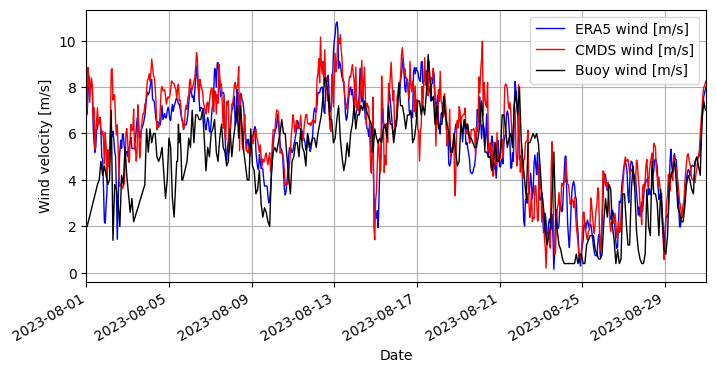

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
# ERA5 series (set line color to black)
ax.plot(df_ERA5["date"], df_ERA5["wind_velocity"], label="ERA5 wind [m/s]", color="blue", linestyle="-", linewidth=1.0)

# Serie del modelo CMDS
ax.plot(df.index, df["wind_velocity"], label="CMDS wind [m/s]", color="red", linestyle="-", linewidth=1.0)
# Buoy series
ax.plot(df_buoy.index, df_buoy["Wind[m/s]"], label="Buoy wind [m/s]", color="black", linestyle="-", linewidth=1.0)



# ---- Set the date window on the x-axis (place AFTER plotting) ----
# Use any date range you need; ensure these are pandas Timestamps or datetimes
start_date = pd.Timestamp("2023-08-01")
end_date   = pd.Timestamp("2023-08-31")
ax.set_xlim(start_date, end_date)

# Etiquetas y formato
ax.set_xlabel("Date")
ax.set_ylabel("Wind velocity [m/s]")
ax.legend()
ax.grid(True)
fig.autofmt_xdate()

plt.show()

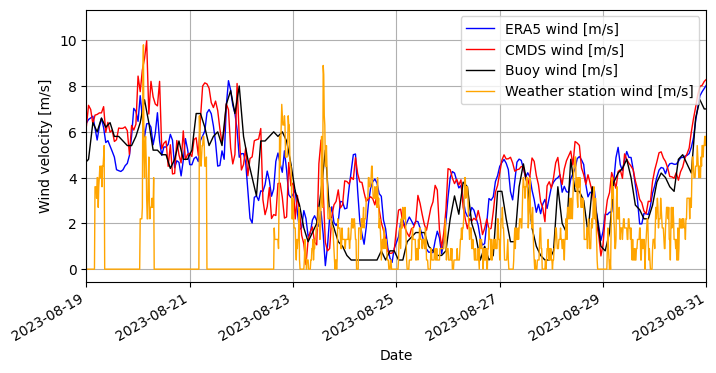

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
# ERA5 series (set line color to black)
ax.plot(df_ERA5["date"], df_ERA5["wind_velocity"], label="ERA5 wind [m/s]", color="blue", linestyle="-", linewidth=1.0)

# Serie del modelo CMDS
ax.plot(df.index, df["wind_velocity"], label="CMDS wind [m/s]", color="red", linestyle="-", linewidth=1.0)
# Buoy series
ax.plot(df_buoy.index, df_buoy["Wind[m/s]"], label="Buoy wind [m/s]", color="black", linestyle="-", linewidth=1.0)
#
ax.plot(davis_df.index, davis_df["Speed"], label="Weather station wind [m/s]", color="orange", linestyle="-", linewidth=1.0)

# ---- Set the date window on the x-axis (place AFTER plotting) ----
# Use any date range you need; ensure these are pandas Timestamps or datetimes
start_date = pd.Timestamp("2023-08-19")
end_date   = pd.Timestamp("2023-08-31")
ax.set_xlim(start_date, end_date)

# Etiquetas y formato
ax.set_xlabel("Date")
ax.set_ylabel("Wind velocity [m/s]")
ax.legend()
ax.grid(True)
fig.autofmt_xdate()

plt.show()

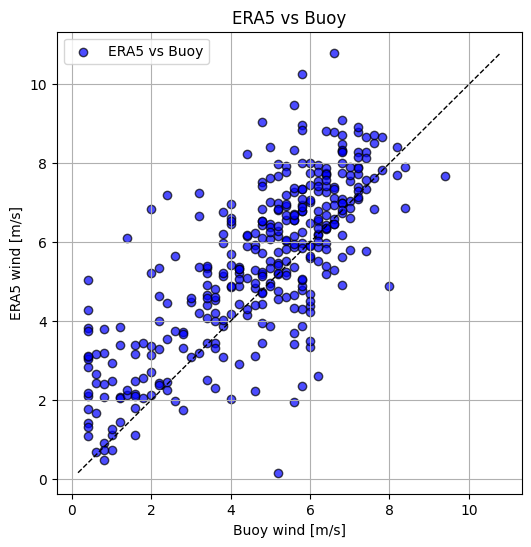

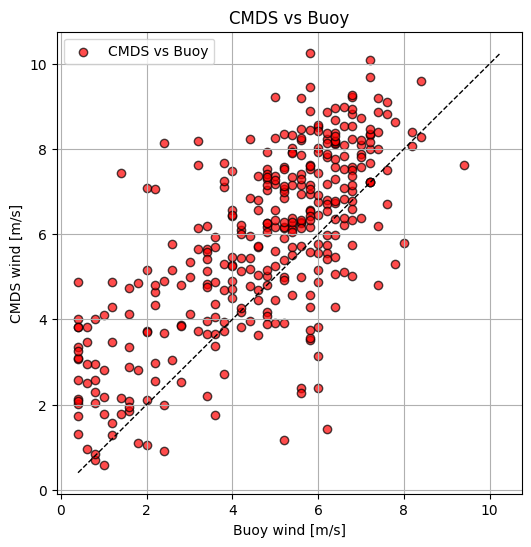

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------- Configurable date window --------------------- #
start_date = pd.Timestamp("2023-08-01")
end_date   = pd.Timestamp("2023-08-31")

# --------------------- Helper to make a clean 'date' column -------- #
def ensure_date_column_from_index(df_in) -> pd.DataFrame:
    """
    Return a copy with a plain 'date' column (tz-naive) derived from the index,
    and WITHOUT any datetime index name that could collide with 'date'.
    """
    df = df_in.copy()
    # Force datetime index
    idx = pd.to_datetime(df.index)
    # Drop timezone if present (robust to both tz-aware and tz-naive)
    try:
        idx = idx.tz_convert(None)
    except Exception:
        try:
            idx = idx.tz_localize(None)
        except Exception:
            pass
    df = df.copy()
    df.index = idx
    df.index.name = None  # avoid name collisions
    df = df.reset_index().rename(columns={"index": "date"})
    return df

def ensure_date_column_from_col(df_in, col: str) -> pd.DataFrame:
    """
    Return a copy with a plain 'date' column (tz-naive) derived from df[col],
    and drop timezone if present. Keeps original index untouched.
    """
    df = df_in.copy()
    dates = pd.to_datetime(df[col])
    try:
        dates = dates.dt.tz_convert(None)
    except Exception:
        try:
            dates = dates.dt.tz_localize(None)
        except Exception:
            pass
    df["date"] = dates
    return df

# --------------------- Standardize inputs to have 'date' ------------- #
# Buoy: time in the index
buoy_std = ensure_date_column_from_index(df_buoy)
buoy_std = buoy_std.rename(columns={"Wind[m/s]": "buoy_wind"})

# ERA5: time in a 'date' column (rename/create uniformly)
if "date" in df_ERA5.columns:
    era5_std = ensure_date_column_from_col(df_ERA5, "date")
else:
    # If ERA5 time is in the index, fall back to index
    era5_std = ensure_date_column_from_index(df_ERA5)
era5_std = era5_std.rename(columns={"wind_velocity": "era5_wind"})

# CMDS: accept either datetime index or a 'date' column
if "date" in df.columns:
    cmds_std = ensure_date_column_from_col(df, "date")
else:
    cmds_std = ensure_date_column_from_index(df)
cmds_std = cmds_std.rename(columns={"wind_velocity": "cmds_wind"})

# --------------------- Slice by date window -------------------------- #
buoy_slice = buoy_std.loc[(buoy_std["date"] >= start_date) & (buoy_std["date"] <= end_date), ["date", "buoy_wind"]]
era5_slice = era5_std.loc[(era5_std["date"] >= start_date) & (era5_std["date"] <= end_date), ["date", "era5_wind"]]
cmds_slice = cmds_std.loc[(cmds_std["date"] >= start_date) & (cmds_std["date"] <= end_date), ["date", "cmds_wind"]]

# --------------------- Align (inner join on 'date') ------------------ #
era5_pairs = pd.merge(buoy_slice, era5_slice, on="date", how="inner").dropna(subset=["buoy_wind", "era5_wind"])
cmds_pairs = pd.merge(buoy_slice, cmds_slice, on="date", how="inner").dropna(subset=["buoy_wind", "cmds_wind"])

# --------------------- Scatter ERA5 vs Buoy -------------------------- #
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(era5_pairs["buoy_wind"], era5_pairs["era5_wind"],
           color="blue", alpha=0.7, edgecolors="k", label="ERA5 vs Buoy")

mn = float(min(era5_pairs["buoy_wind"].min(), era5_pairs["era5_wind"].min()))
mx = float(max(era5_pairs["buoy_wind"].max(), era5_pairs["era5_wind"].max()))
ax.plot([mn, mx], [mn, mx], "k--", lw=1)  # 1:1 line

ax.set_xlabel("Buoy wind [m/s]")
ax.set_ylabel("ERA5 wind [m/s]")
ax.set_title("ERA5 vs Buoy")
ax.grid(True)
ax.legend()
plt.show()

# --------------------- Scatter CMDS vs Buoy -------------------------- #
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(cmds_pairs["buoy_wind"], cmds_pairs["cmds_wind"],
           color="red", alpha=0.7, edgecolors="k", label="CMDS vs Buoy")

mn = float(min(cmds_pairs["buoy_wind"].min(), cmds_pairs["cmds_wind"].min()))
mx = float(max(cmds_pairs["buoy_wind"].max(), cmds_pairs["cmds_wind"].max()))
ax.plot([mn, mx], [mn, mx], "k--", lw=1)  # 1:1 line

ax.set_xlabel("Buoy wind [m/s]")
ax.set_ylabel("CMDS wind [m/s]")
ax.set_title("CMDS vs Buoy")
ax.grid(True)
ax.legend()
plt.show()


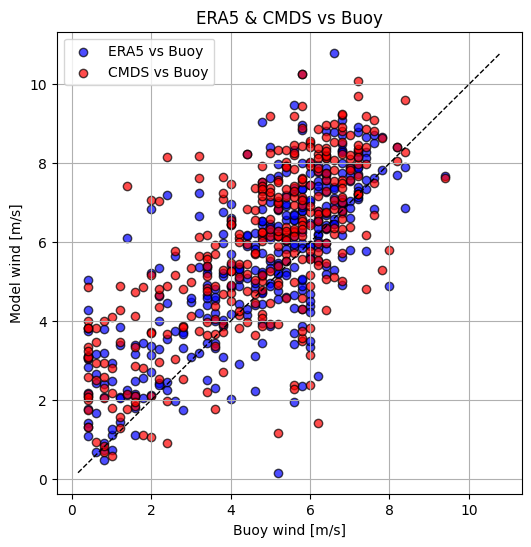

In [14]:
# --------------------- Combined scatter ERA5 & CMDS vs Buoy --------------------- #
fig, ax = plt.subplots(figsize=(6, 6))

# ERA5 scatter
ax.scatter(era5_pairs["buoy_wind"], era5_pairs["era5_wind"],
           color="blue", alpha=0.7, edgecolors="k", label="ERA5 vs Buoy")

# CMDS scatter
ax.scatter(cmds_pairs["buoy_wind"], cmds_pairs["cmds_wind"],
           color="red", alpha=0.7, edgecolors="k", label="CMDS vs Buoy")

# Common 1:1 reference line
mn = float(min(
    era5_pairs["buoy_wind"].min(), era5_pairs["era5_wind"].min(),
    cmds_pairs["buoy_wind"].min(), cmds_pairs["cmds_wind"].min()
))
mx = float(max(
    era5_pairs["buoy_wind"].max(), era5_pairs["era5_wind"].max(),
    cmds_pairs["buoy_wind"].max(), cmds_pairs["cmds_wind"].max()
))
ax.plot([mn, mx], [mn, mx], "k--", lw=1)

# Labels and legend
ax.set_xlabel("Buoy wind [m/s]")
ax.set_ylabel("Model wind [m/s]")
ax.set_title("ERA5 & CMDS vs Buoy")
ax.grid(True)
ax.legend()
plt.show()
